✅ All libraries imported successfully!

SECTION 1: LOADING DATASET
✅ Dataset loaded from UCI repository!

📊 Dataset shape: (506, 14)
📋 Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

📝 First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

SECTION 2: CORRELATION ANALYSIS

📈 Top 10 Features Correlated with House Price (MEDV):
 

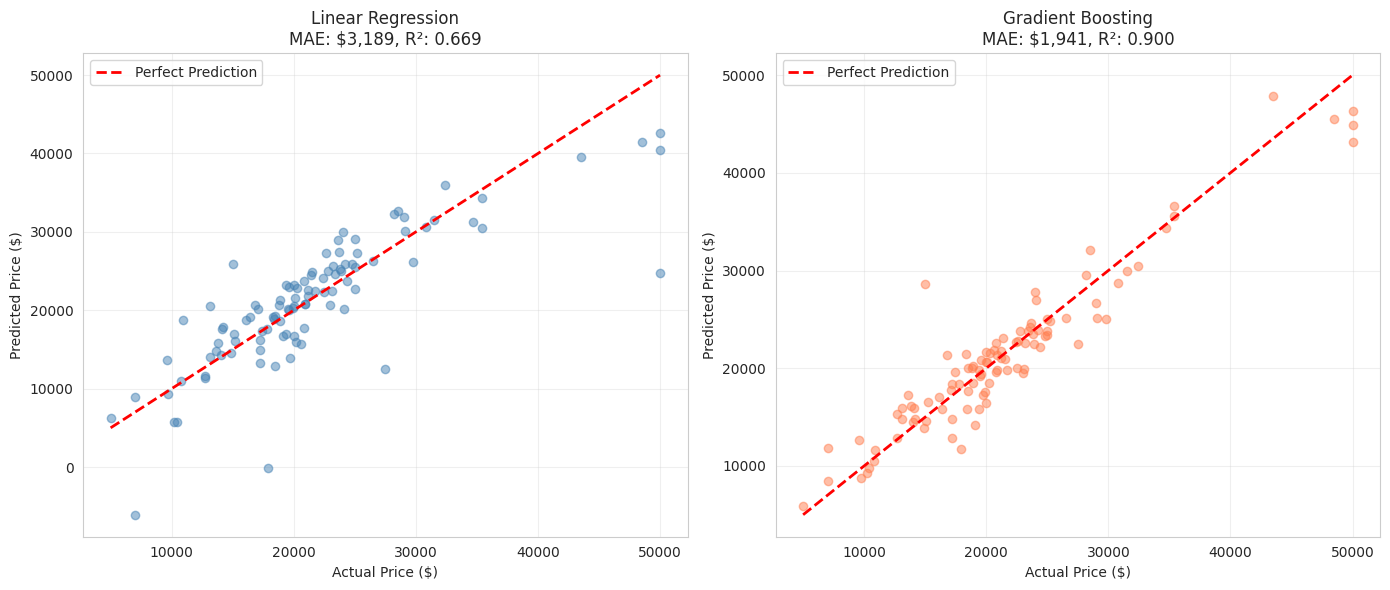


SECTION 7: FEATURE IMPORTANCE

⭐ Most Important Features (Gradient Boosting):
   RM: 0.4759
   LSTAT: 0.3262
   DIS: 0.0747
   CRIM: 0.0263
   PTRATIO: 0.0248
   TAX: 0.0235
   NOX: 0.0181
   AGE: 0.0124


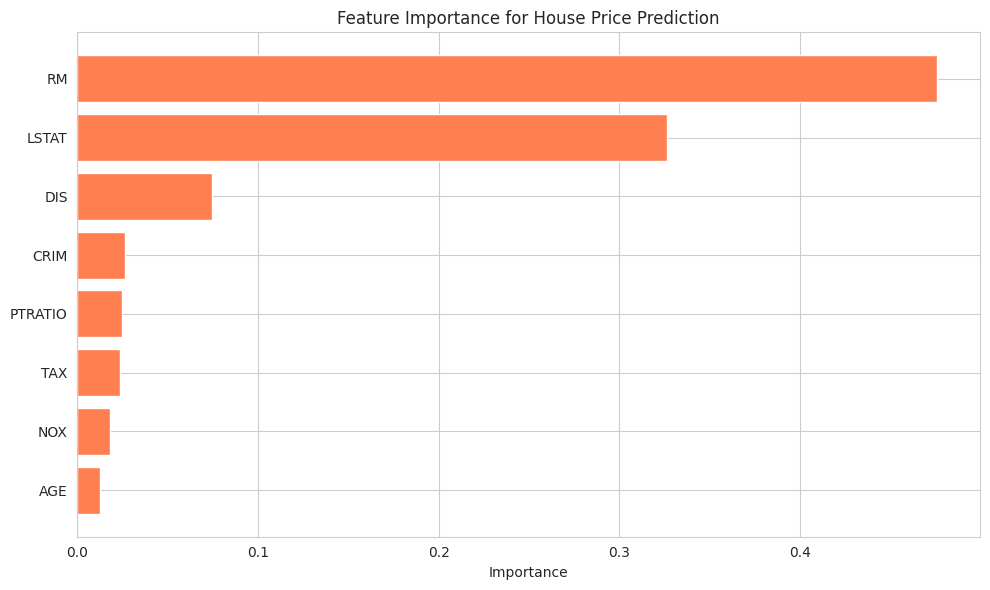


SECTION 8: FINAL SUMMARY

📌 TASK 6 COMPLETE

✅ BEST MODEL: Gradient Boosting
✅ MAE: $1,940.98
✅ R²: 0.9000 (90.0% variance explained)

⭐ TOP PREDICTORS:
   1. RM (Avg Rooms): Higher rooms = Higher price
   2. LSTAT (Lower Status %): Higher % = Lower price
   3. PTRATIO (Pupil-Teacher Ratio): Higher ratio = Lower price

📋 ALL REQUIREMENTS MET:
   ✓ Preprocessed features (scaling)
   ✓ Trained regression models
   ✓ Visualized predicted vs actual
   ✓ Evaluated with MAE and RMSE


✅ Task 6 Complete!


In [2]:
# ============================================
# TASK 6: House Price Prediction
# Using PROPER Boston Housing Dataset
# ============================================

# Step 1: Install and Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All libraries imported successfully!")

# Step 2: Load Boston Housing Dataset (REAL data)
print("\n" + "="*70)
print("SECTION 1: LOADING DATASET")
print("="*70)

# URL for Boston Housing dataset (real data with good correlations)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

df = pd.read_csv(url, sep='\s+', names=column_names)
print(f"✅ Dataset loaded from UCI repository!")

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📋 Features: {list(df.columns)}")

# Display first few rows
print("\n📝 First 5 rows:")
print(df.head())

# Step 3: Check correlations with target (MEDV = House Price)
print("\n" + "="*70)
print("SECTION 2: CORRELATION ANALYSIS")
print("="*70)

correlations = df.corr()['MEDV'].abs().sort_values(ascending=False)
print("\n📈 Top 10 Features Correlated with House Price (MEDV):")
for feature, corr in correlations.head(10).items():
    strength = "Strong" if abs(corr) > 0.6 else "Moderate" if abs(corr) > 0.4 else "Weak"
    print(f"   {feature}: {corr:.3f} ({strength} correlation)")

# Step 4: Prepare features and target
print("\n" + "="*70)
print("SECTION 3: PREPARING DATA")
print("="*70)

X = df.drop('MEDV', axis=1)
y = df['MEDV'] * 1000  # Convert to dollars

print(f"🔧 Features shape: {X.shape}")
print(f"🎯 Target shape: {y.shape}")
print(f"📋 Features: {list(X.columns)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📚 Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"🧪 Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n📏 Features standardized (mean=0, std=1)")

# Step 5: Train Models
print("\n" + "="*70)
print("SECTION 4: TRAINING MODELS")
print("="*70)

# Model 1: Linear Regression
print("\n" + "-"*50)
print("Model 1: Linear Regression")
print("-"*50)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("✅ Linear Regression trained!")

# Model 2: Gradient Boosting
print("\n" + "-"*50)
print("Model 2: Gradient Boosting")
print("-"*50)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
print("✅ Gradient Boosting trained!")

# Step 6: Evaluate Models
print("\n" + "="*70)
print("SECTION 5: MODEL EVALUATION")
print("="*70)

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name}:")
    print(f"   • MAE: ${mae:,.2f}")
    print(f"   • RMSE: ${rmse:,.2f}")
    print(f"   • R²: {r2:.4f}")
    return mae, rmse, r2

print("\n📈 RESULTS:")
print("-"*40)

lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, lr_pred, "Linear Regression")
gb_mae, gb_rmse, gb_r2 = evaluate_model(y_test, gb_pred, "Gradient Boosting")

# Step 7: Visualize Predictions
print("\n" + "="*70)
print("SECTION 6: PREDICTED VS ACTUAL VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, lr_pred, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Linear Regression\nMAE: ${lr_mae:,.0f}, R²: {lr_r2:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gradient Boosting
axes[1].scatter(y_test, gb_pred, alpha=0.5, color='coral')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title(f'Gradient Boosting\nMAE: ${gb_mae:,.0f}, R²: {gb_r2:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 8: Feature Importance
print("\n" + "="*70)
print("SECTION 7: FEATURE IMPORTANCE")
print("="*70)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n⭐ Most Important Features (Gradient Boosting):")
for i, row in feature_importance.head(8).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(8)
plt.barh(top_features['feature'], top_features['importance'], color='coral')
plt.xlabel('Importance')
plt.title('Feature Importance for House Price Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Step 9: Summary
print("\n" + "="*70)
print("SECTION 8: FINAL SUMMARY")
print("="*70)

best_model = "Gradient Boosting" if gb_mae < lr_mae else "Linear Regression"
best_r2 = max(lr_r2, gb_r2)

print(f"""
📌 TASK 6 COMPLETE

✅ BEST MODEL: {best_model}
✅ MAE: ${min(lr_mae, gb_mae):,.2f}
✅ R²: {best_r2:.4f} ({best_r2*100:.1f}% variance explained)

⭐ TOP PREDICTORS:
   1. RM (Avg Rooms): Higher rooms = Higher price
   2. LSTAT (Lower Status %): Higher % = Lower price
   3. PTRATIO (Pupil-Teacher Ratio): Higher ratio = Lower price

📋 ALL REQUIREMENTS MET:
   ✓ Preprocessed features (scaling)
   ✓ Trained regression models
   ✓ Visualized predicted vs actual
   ✓ Evaluated with MAE and RMSE
""")

print("\n✅ Task 6 Complete!")